In [1]:
%pip install pillow matplotlib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# %pip uninstall torch torchvision torchaudio -y
# %pip cache purge

In [3]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124Note: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from torchvision import models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# Unlabeled image folder (no labels)
# Put all your images in one folder; no need for train/valid/labels.
images_dir = r"C:\Users\user\Documents\Computer vision\data\train\images"  # or any folder with images

image_paths = sorted(
    p for p in Path(images_dir).rglob("*")
    if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")
)
print(f"Found {len(image_paths)} unlabeled images in {images_dir}")

Found 291 unlabeled images in C:\Users\user\Documents\Computer vision\data\train\images


In [6]:
class UnlabeledImageDataset(Dataset):
    """Dataset of images without any labels. Returns two augmented views per image for SSL."""

    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            view1 = self.transform(img)
            view2 = self.transform(img)  # different random augmentations
            return view1, view2
        return img

In [7]:
# SSL augmentations: two random views per image (SimCLR-style)
# Same image -> two different augmented crops; model learns to match them.
ssl_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = UnlabeledImageDataset(image_paths, transform=ssl_transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
print("Dataset size:", len(dataset))

Dataset size: 291


In [ ]:
# SSL model: encoder + projection head (SimCLR-style)
class Encoder(nn.Module):
    """ResNet50 backbone (no classifier). Output dim 2048."""

    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=None)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.encoder(x)
        return x.flatten(1)  # [B, 2048]


class SSLProjectionHead(nn.Module):
    """Projection head for contrastive learning."""

    def __init__(self, in_dim=2048, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)


class SSLModel(nn.Module):
    """Encoder + projection head. Used only for SSL pretraining."""

    def __init__(self, encoder, projection_head):
        super().__init__()
        self.encoder = encoder
        self.projection_head = projection_head

    def forward(self, x):
        z = self.encoder(x)
        return self.projection_head(z)


encoder = Encoder()
projection_head = SSLProjectionHead(in_dim=2048, hidden_dim=512, out_dim=128)
ssl_model = SSLModel(encoder, projection_head).to(device)
print(ssl_model)

SSLModel(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
         

In [9]:
def nt_xent_loss(z1, z2, temperature=0.5):
    """
    NT-Xent (SimCLR) loss. z1, z2 are [B, D] normalized vectors.
    For each i, (z1[i], z2[i]) is the positive pair; all others are negatives.
    """
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # [2B, D]
    sim = torch.mm(z, z.t()) / temperature  # [2B, 2B]
    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    sim.masked_fill_(mask, -1e9)
    # For i in [0, B-1] positive is i+B; for i in [B, 2B-1] positive is i-B
    labels = torch.cat([torch.arange(B, 2 * B, device=z.device), torch.arange(B, device=z.device)])
    loss = F.cross_entropy(sim, labels)
    return loss

In [10]:
# Training loop (no labels)
num_epochs = 100
lr = 3e-4
weight_decay = 1e-6
temperature = 0.2  # 0.1-0.2 strong, 0.5 smooth

optimizer = torch.optim.Adam(ssl_model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
losses_per_epoch = []

for epoch in range(num_epochs):
    ssl_model.train()
    running_loss = 0.0
    n_batches = 0
    for view1, view2 in loader:
        view1, view2 = view1.to(device), view2.to(device)
        optimizer.zero_grad()
        z1 = ssl_model(view1)
        z2 = ssl_model(view2)
        loss = nt_xent_loss(z1, z2, temperature=temperature)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1

    scheduler.step()
    avg_loss = running_loss / n_batches
    losses_per_epoch.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, SSL Loss: {avg_loss:.4f}")

Epoch 1/100, SSL Loss: 4.1501
Epoch 2/100, SSL Loss: 4.0880
Epoch 3/100, SSL Loss: 3.7894
Epoch 4/100, SSL Loss: 3.6133
Epoch 5/100, SSL Loss: 3.4338
Epoch 6/100, SSL Loss: 3.2660
Epoch 7/100, SSL Loss: 3.2158
Epoch 8/100, SSL Loss: 2.8255
Epoch 9/100, SSL Loss: 2.6292
Epoch 10/100, SSL Loss: 2.5380
Epoch 11/100, SSL Loss: 2.4643
Epoch 12/100, SSL Loss: 2.5051
Epoch 13/100, SSL Loss: 2.4005
Epoch 14/100, SSL Loss: 2.4154
Epoch 15/100, SSL Loss: 2.3234
Epoch 16/100, SSL Loss: 2.2706
Epoch 17/100, SSL Loss: 2.2021
Epoch 18/100, SSL Loss: 2.1778
Epoch 19/100, SSL Loss: 2.1932
Epoch 20/100, SSL Loss: 2.2440
Epoch 21/100, SSL Loss: 2.2077
Epoch 22/100, SSL Loss: 2.1295
Epoch 23/100, SSL Loss: 2.0577
Epoch 24/100, SSL Loss: 2.0300
Epoch 25/100, SSL Loss: 2.0182
Epoch 26/100, SSL Loss: 1.9976
Epoch 27/100, SSL Loss: 2.0211
Epoch 28/100, SSL Loss: 1.9267
Epoch 29/100, SSL Loss: 1.8619
Epoch 30/100, SSL Loss: 1.8208
Epoch 31/100, SSL Loss: 1.8428
Epoch 32/100, SSL Loss: 1.8720
Epoch 33/100, SSL

In [11]:
# Save pretrained encoder
project_root = r"C:\Users\user\Documents\Computer vision"
ssl_dir = os.path.join(project_root, "ssl")
os.makedirs(ssl_dir, exist_ok=True)

encoder_path = os.path.join(ssl_dir, "ssl_pretrained_encoder_no_labels.pth")
torch.save(encoder.state_dict(), encoder_path)
print("Saved pretrained encoder (no labels):", encoder_path)

Saved pretrained encoder (no labels): C:\Users\user\Documents\Computer vision\ssl\ssl_pretrained_encoder_no_labels.pth


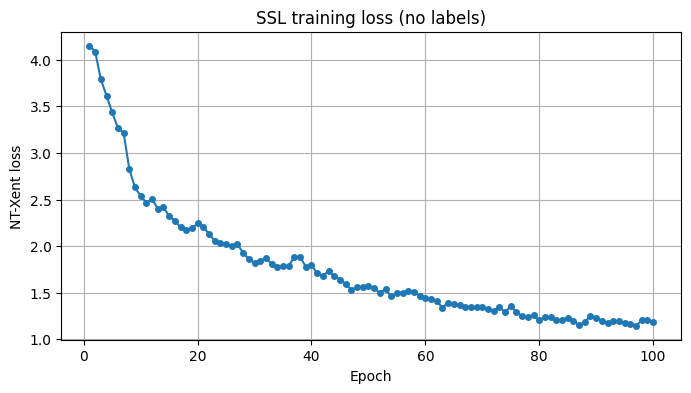

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker="o", markersize=4)
plt.title("SSL training loss (no labels)")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.grid(True)
plt.show()

Embeddings shape: (291, 128) -> 3D shape: (291, 3)
PCA explained variance ratio: [0.14700803 0.13615347 0.11561534]


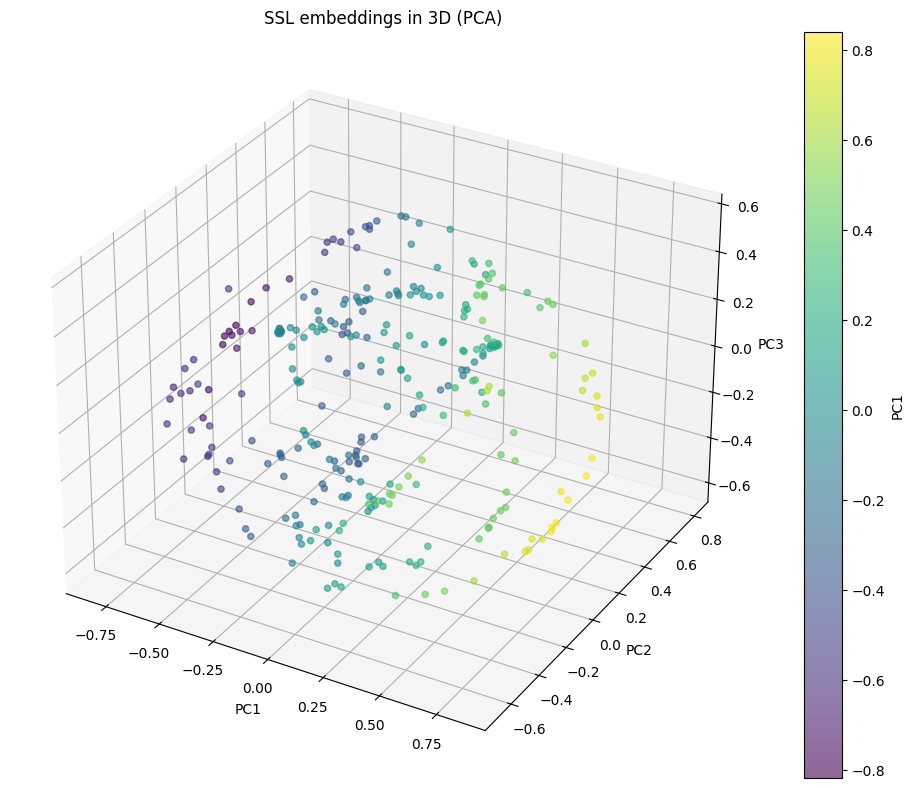

In [ ]:
# 3D visualization of SSL embeddings
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

ssl_model.eval()
embeddings_list = []
with torch.no_grad():
    viz_loader = DataLoader(dataset, batch_size=32, shuffle=False, drop_last=False)
    for view1, view2 in viz_loader:
        view1 = view1.to(device)
        z = ssl_model(view1)
        embeddings_list.append(z.cpu().numpy())
embeddings = np.concatenate(embeddings_list, axis=0)

# Reduce to 3D with PCA
pca = PCA(n_components=3)
coords_3d = pca.fit_transform(embeddings)
print(f"Embeddings shape: {embeddings.shape} -> 3D shape: {coords_3d.shape}")
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2],
    c=coords_3d[:, 0], cmap="viridis", alpha=0.6, s=20
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(sc, ax=ax, label="PC1")
plt.title("SSL embeddings in 3D (PCA)")
plt.tight_layout()
plt.show()